In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as Thien

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

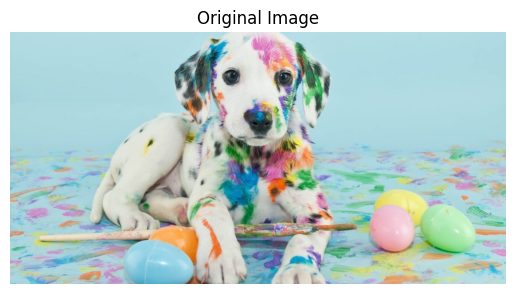

In [20]:
img = cv.imread('hinh1.jpg')
img2 = cv.imread('hinh2.jpg')

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

Thien.imshow(img_rgb)
Thien.title("Original Image")
Thien.axis('off')

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

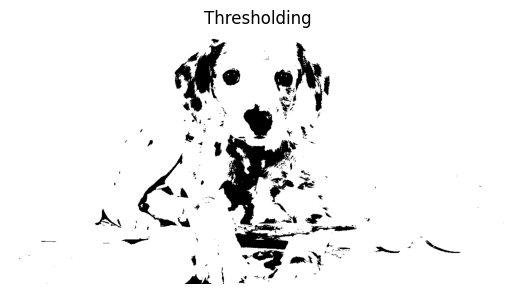

In [21]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

Thien.imshow(thresh, cmap='gray')
Thien.title("Thresholding")
Thien.axis('off')

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

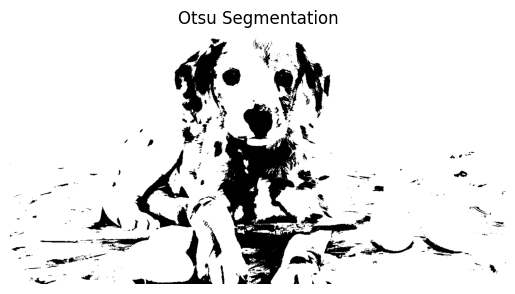

In [22]:
_, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

Thien.imshow(otsu, cmap='gray')
Thien.title("Otsu Segmentation")
Thien.axis('off')

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

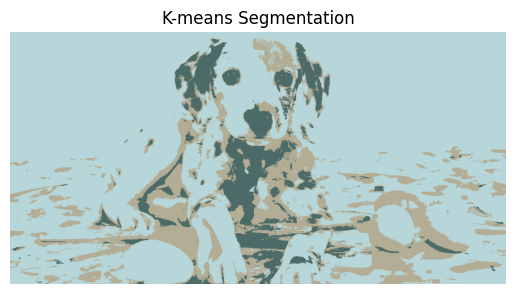

In [23]:
Z = img.reshape((-1,3))
Z = np.float32(Z)

K = 3
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

ret, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
segmented = res.reshape((img.shape))

Thien.imshow(cv.cvtColor(segmented, cv.COLOR_BGR2RGB))
Thien.title("K-means Segmentation")
Thien.axis('off')

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

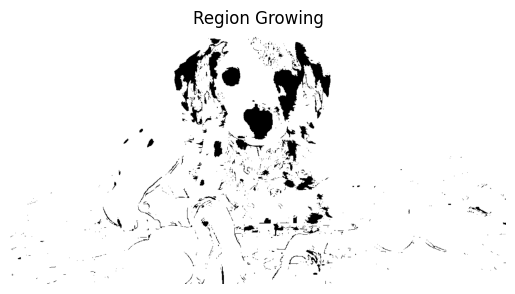

In [24]:
def region_growing(img, seed, threshold=10):
    h, w = img.shape
    segmented = np.zeros((h, w), np.uint8)
    visited = np.zeros((h, w), np.bool_)

    stack = [seed]

    while stack:
        x, y = stack.pop()

        if visited[x, y]:
            continue

        visited[x, y] = True
        segmented[x, y] = 255

        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x+dx, y+dy

            if 0 <= nx < h and 0 <= ny < w:
                if not visited[nx, ny]:
                    if abs(int(img[x,y]) - int(img[nx,ny])) < threshold:
                        stack.append((nx, ny))

    return segmented

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
rg = region_growing(gray, (100, 100))

Thien.imshow(rg, cmap='gray')
Thien.title("Region Growing")
Thien.axis('off')

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

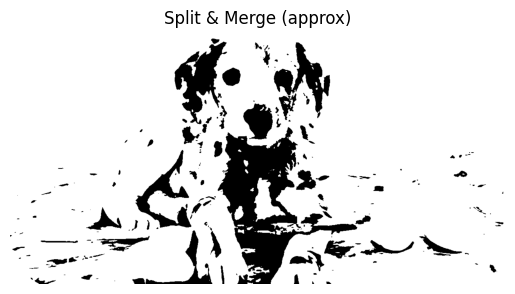

In [25]:

blur = cv.GaussianBlur(gray, (5,5), 0)
_, split_merge = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

Thien.imshow(split_merge, cmap='gray')
Thien.title("Split & Merge (approx)")
Thien.axis('off')

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

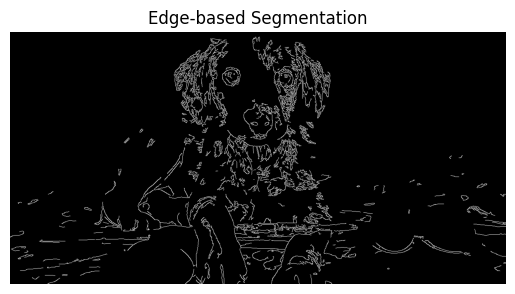

In [26]:
edges = cv.Canny(gray, 100, 200)

Thien.imshow(edges, cmap='gray')
Thien.title("Edge-based Segmentation")
Thien.axis('off')